# InsureX Campaign Response — Exploratory Data Analysis

**Dataset:** `dsc_test_case.csv`  
**Rows:** 215,993 | **Columns:** 26  
**Target variable:** `label` (0 = Reject, 1 = PA Insurance, 2 = Life Insurance)

**Objective:** วิเคราะห์ข้อมูลลูกค้าเพื่อทำความเข้าใจพฤติกรรมการตอบรับแคมเปญประกันภัย  
และค้นหา customer persona สำหรับออกแบบ targeted campaign ที่มีประสิทธิภาพ

---

## Load Data 

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/ppraew/Desktop/insurex/dsc_test_case.csv')
print("Shape:", df.shape)

Shape: (215993, 26)


### Initial Data Inspection

In [47]:
print("Data Types:")
print(df.dtypes)

Data Types:
campaign_month            object
marital_sta               object
main_occupation           object
customer_segment          object
gender                    object
have_acc_planet           object
have_cc                   object
scb_payroll               object
num_children             float64
age                      float64
income                   float64
maxosdc_last_30d         float64
dcspend_last_30d         float64
easypymt_last_30d        float64
savacc_bal               float64
currentacc_bal           float64
avg_savaccbal_30d        float64
avg_currentaccbal_30d    float64
mob                      float64
inflow30d                float64
outflow30d               float64
inflow1_15               float64
outflow1_15              float64
net_flow_30d             float64
net_flow_15d             float64
label                      int64
dtype: object


In [48]:
print("\nFirst 5 Rows:")
print(df.head())
print("\nDataFrame Info:")
df.info()
print("\nDataFrame Description:")
df.describe()


First 5 Rows:
  campaign_month     marital_sta main_occupation customer_segment  gender   
0            Mar             โสด      Salary man       Lower Mass  Female  \
1            Jul            สมรส      Salary man             Mass  Female   
2            Jan             โสด   Self-employed       Lower Mass    Male   
3            Nov             โสด      Salary man             Mass  Female   
4            Oct  สมรสจด ทะเบียน      Salary man             Mass  Female   

  have_acc_planet have_cc scb_payroll  num_children   age  ...   
0               N       N           Y           0.0  41.0  ...  \
1               N       N           N           1.0  46.0  ...   
2               N       N           N           0.0  36.0  ...   
3               N       N           N           0.0  38.0  ...   
4               N       N           N           0.0  41.0  ...   

   avg_savaccbal_30d  avg_currentaccbal_30d    mob  inflow30d  outflow30d   
0            2034.46                    0.0   77

,num_children,age,income,maxosdc_last_30d,dcspend_last_30d,easypymt_last_30d,savacc_bal,currentacc_bal,avg_savaccbal_30d,avg_currentaccbal_30d,mob,inflow30d,outflow30d,inflow1_15,outflow1_15,net_flow_30d,net_flow_15d,label
count,214493.000000,214493.000000,213592.000000,2.135920e+05,2.135920e+05,2.135920e+05,2.135920e+05,213592.000000,2.135920e+05,2.135920e+05,213592.000000,2.135920e+05,2.135920e+05,2.135920e+05,2.135920e+05,2.135920e+05,2.135920e+05,215993.000000
mean,0.040388,37.784515,16867.350481,1.135482e+04,1.653663e+02,1.196368e+03,2.085630e+04,0.001217,1.517568e+04,3.042249e+01,54.562409,2.528975e+04,2.554592e+04,2.528975e+04,2.554592e+04,-2.561721e+02,-2.561721e+02,0.016714
std,0.250050,9.589737,19992.802475,5.844912e+04,7.403789e+03,8.443915e+03,9.490667e+04,0.034868,6.979798e+04,3.943841e+03,66.371776,1.229048e+05,1.214443e+05,1.229048e+05,1.214443e+05,2.522841e+04,2.522841e+04,0.159946
min,0.000000,23.000000,0.000000,0.000000e+00,-8.703088e+04,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.813780e+06,-1.813780e+06,0.000000
25%,0.000000,30.000000,4364.980000,0.000000e+00,0.000000e+00,8.800000e+01,7.350000e+00,0.000000,1.229200e+02,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.600000e-01,-1.600000e-01,0.000000
50%,0.000000,36.000000,12252.610000,0.000000e+00,0.000000e+00,3.730000e+02,8.006550e+02,0.000000,9.929200e+02,0.000000e+00,40.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
75%,0.000000,45.000000,21166.587500,4.037855e+03,0.000000e+00,9.250000e+02,7.557888e+03,0.000000,4.643622e+03,0.000000e+00,77.000000,1.690749e+04,1.829000e+04,1.690749e+04,1.829000e+04,0.000000e+00,0.000000e+00,0.000000
max,21.000000,61.000000,199625.670000,4.374289e+06,1.852988e+06,2.000000e+06,4.793828e+06,1.000000,2.471113e+06,1.232520e+06,887.000000,2.147169e+07,2.147169e+07,2.147169e+07,2.147169e+07,2.295697e+06,2.295697e+06,2.000000


In [49]:
#ดู unique values ของ categorical columns แบบแยกทีละตัว 
cat_cols = ['campaign_month','marital_sta','main_occupation',
            'customer_segment','gender','have_acc_planet','have_cc','scb_payroll']

for col in cat_cols:
    print(f"{col}: {df[col].unique()}")


campaign_month: ['Mar' 'Jul' 'Jan' 'Nov' 'Oct' 'Sep' 'Apr' 'Jun' 'Dec' 'Feb' 'Aug' 'May']
marital_sta: ['โสด' 'สมรส' 'สมรสจด ทะเบียน' 'หย่าร้าง' 'ม่าย' 'อื่นๆ' nan
 'สมรสไม่ จดทะเบียน' 'แยกกันอยู่']
main_occupation: ['Salary man' 'Self-employed' 'Freelance' 'Housewife' 'Student'
 'Professional' 'Unemployed' 'Government' nan 'Other/Unknown'
 'Entertainer']
customer_segment: ['Lower Mass' 'Mass' 'Upper Mass' nan]
gender: ['Female' 'Male' nan]
have_acc_planet: ['N' 'Y' nan]
have_cc: ['N' 'Y' nan]
scb_payroll: ['Y' 'N' nan]


In [50]:
#ดู label distribution:
df['label'].value_counts()


label
0    213371
1      1634
2       988
Name: count, dtype: int64

## Find Missing Values

In [51]:
df.isnull().sum()

campaign_month              0
marital_sta              4635
main_occupation          1500
customer_segment         1500
gender                   1500
have_acc_planet          2401
have_cc                  1500
scb_payroll              1500
num_children             1500
age                      1500
income                   2401
maxosdc_last_30d         2401
dcspend_last_30d         2401
easypymt_last_30d        2401
savacc_bal               2401
currentacc_bal           2401
avg_savaccbal_30d        2401
avg_currentaccbal_30d    2401
mob                      2401
inflow30d                2401
outflow30d               2401
inflow1_15               2401
outflow1_15              2401
net_flow_30d             2401
net_flow_15d             2401
label                       0
dtype: int64

This section summarizes the count and percentage of missing values for each feature.

In [52]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2) #missing_count ÷ จำนวนทั้งหมด × 100 = % ที่หายไป
#missing / len(df) -> หารด้วยจำนวนแถวทั้งหมดเพื่อหาสัดส่วนของ missing values
#* 100 -> แปลงเป็นเปอร์เซ็นต์
#.round(2) -> ปัดเศษทศนิยมให้เหลือ 2 ตำแหน่ง

missing_df = pd.DataFrame({
        'missing_count': missing,
        'missing_%' : missing_pct,
    })

missing_df[missing_df['missing_count'] > 0]

,missing_count,missing_%
marital_sta,4635,2.15
main_occupation,1500,0.69
customer_segment,1500,0.69
gender,1500,0.69
have_acc_planet,2401,1.11
have_cc,1500,0.69
scb_payroll,1500,0.69
num_children,1500,0.69
age,1500,0.69
income,2401,1.11


## Missing Value Analysis

### กลุ่ม A: ข้อมูลด้านประชากรศาสตร์ (Demographic Features)

พบข้อมูลที่หายไปจำนวน 1,500 รายการ ในตัวแปรที่เกี่ยวข้องกับข้อมูลประชากรศาสตร์ ได้แก่ สถานภาพสมรส อาชีพ กลุ่มลูกค้า เพศ การถือครองบัตรเครดิต สถานะเงินเดือน จำนวนบุตร และอายุ

### กลุ่ม B: ข้อมูลด้านการเงิน (Financial Features)

พบข้อมูลที่หายไปจำนวน 2,401 รายการ ในตัวแปรที่เกี่ยวข้องกับข้อมูลทางการเงิน ได้แก่ รายได้ (income), have_acc_planet และตัวแปรทางการเงินอื่น ๆ

### ข้อสังเกตสำคัญ

- Missing values มีการกระจุกตัวอยู่ในกลุ่มตัวแปรเฉพาะ แทนที่จะกระจายแบบสุ่ม
- ตัวแปร **marital_sta** มีจำนวนข้อมูลที่หายไปมากที่สุด โดยมีข้อมูลหายไป **4,635 รายการ**

In [53]:
# ดูว่า rows ที่ missing financial data มี label เป็นอะไรบ้าง
missing_financial = df[df['income'].isnull()]
print(missing_financial['label'].value_counts())
print(f"Total: {len(missing_financial)}")


label
0    2395
2       5
1       1
Name: count, dtype: int64
Total: 2401


## Numeric Feature Distribution & Outlier Detection

ตรวจสอบ distribution ของตัวแปรตัวเลขโดยเปรียบเทียบค่า min / median / max  
เพื่อหาค่าผิดปกติที่ควรตรวจสอบก่อนนำข้อมูลไปสร้างโมเดล

In [54]:
outlier_check = df[['age', 'mob', 'dcspend_last_30d', 'currentacc_bal', 'income']].describe().loc[['min', '50%', 'max']]
print("Outlier check — min / median / max:")
print(outlier_check.round(2))
print()
print(f"mob max       : {df['mob'].max():.0f} months = {df['mob'].max()/12:.1f} years  (ลูกค้าอายุสูงสุด 61 ปี → น่าเป็น data error)")
print(f"dcspend min   : {df['dcspend_last_30d'].min():,.2f}  (spending field ไม่ควรติดลบ)")
print(f"currentacc_bal unique: {sorted(df['currentacc_bal'].dropna().unique())}  (ค่าควรเป็ยอดเงิน แต่มีแค่ 0/1 → น่าเป็น binary flag)")

Outlier check — min / median / max:
      age    mob  dcspend_last_30d  currentacc_bal     income
min  23.0    0.0         -87030.88             0.0       0.00
50%  36.0   40.0              0.00             0.0   12252.61
max  61.0  887.0        1852987.91             1.0  199625.67

mob max       : 887 months = 73.9 years  (ลูกค้าอายุสูงสุด 61 ปี → น่าเป็น data error)
dcspend min   : -87,030.88  (spending field ไม่ควรติดลบ)
currentacc_bal unique: [0.0, 1.0]  (ค่าควรเป็ยอดเงิน แต่มีแค่ 0/1 → น่าเป็น binary flag)


### ยืนยัน: currentacc_bal เป็น Binary Flag ไม่ใช่ยอดเงิน

In [55]:
df['currentacc_bal'].value_counts()


currentacc_bal
0.0    213332
1.0       260
Name: count, dtype: int64

## Feature Analysis vs Campaign Response

วิเคราะห์ความสัมพันธ์ระหว่าง features กับ target label  
เพื่อระบุตัวแปรที่มีอิทธิพลต่อการตัดสินใจรับหรือปฏิเสธ offer และค้นหา customer persona

In [56]:
pd.crosstab(df['customer_segment'], df['label'], normalize='index') * 100
#แสดง % ของแต่ละ label ภายใน segment นั้นๆ เช่น ในกลุ่ม "Mass" มีกี่ % ที่ accept offer (label 1, 2) เทียบกับปฏิเสธ (label 0)

label,0,1,2
customer_segment,,,
Lower Mass,98.738000,0.886914,0.375087
Mass,98.820316,0.652766,0.526919
Upper Mass,98.785602,0.532937,0.681461


Lower Mass → รับ PA Insurance สูงสุด (อาจเพราะเบี้ยถูก ต้องการความคุ้มครองพื้นฐาน)
Upper Mass → รับ Life Insurance สูงสุด (รายได้สูงกว่า จึงพร้อมจ่ายเบี้ยที่สูงกว่าเพื่อ wealth/legacy planning)

### Numeric Features vs Label — Age & Income

เปรียบเทียบอายุและรายได้เฉลี่ยของลูกค้าแต่ละกลุ่ม เพื่อยืนยัน customer persona

In [57]:
df.groupby('label')[['age', 'income']].mean()


,age,income
label,,
0,37.809437,16863.223215
1,36.508267,15748.408855
2,34.549595,19611.995178


ลูกค้าที่ อายุน้อยกว่า มีแนวโน้มตอบรับ offer มากกว่ากลุ่มอายุเยอะ และกลุ่มที่ตอบรับ Life Insurance เป็นกลุ่มที่ อายุน้อยที่สุดแต่รายได้สูงที่สุด (อาจเป็นกลุ่มวัยทำงานเริ่มต้น/มีรายได้ดี กำลังมองหาการวางแผนระยะยาว) ในขณะที่กลุ่ม PA Insurance มีรายได้ต่ำกว่าค่าเฉลี่ย (มองหาความคุ้มครองพื้นฐานราคาประหยัด)

### Product Ownership vs Campaign Response (Cross-sell Analysis)

ตรวจสอบว่าลูกค้าที่มีผลิตภัณฑ์ธนาคารอยู่แล้ว (บัตรเครดิต, payroll account, travel account)  
มีแนวโน้มตอบรับแคมเปญประกันภัยต่างจากลูกค้าทั่วไปอย่างไร

In [58]:
for col in ['have_cc', 'scb_payroll', 'have_acc_planet']:
    print(f"--- {col} ---")
    print(pd.crosstab(df[col], df['label'], normalize='index') * 100)
    print()


--- have_cc ---
label            0         1         2
have_cc                               
N        98.749650  0.810604  0.439746
Y        99.033929  0.317357  0.648714

--- scb_payroll ---
label                0         1         2
scb_payroll                               
N            98.822696  0.737426  0.439878
Y            98.603875  0.854584  0.541541

--- have_acc_planet ---
label                    0        1         2
have_acc_planet                              
N                98.768122  0.77367  0.458207
Y                99.211679  0.20438  0.583942



มี 2 customer persona ชัดเจน — กลุ่ม "เริ่มต้น มองหาความคุ้มครองพื้นฐานราคาประหยัด" (PA) vs กลุ่ม "มีฐานะ ผูกพันกับธนาคารอยู่แล้ว มองหาการวางแผนระยะยาว" (Life) — สามารถใช้ทำ targeted campaign แยกตาม persona ได้ทันที

## สรุป Key Findings

### 1. Dataset Overview
- ข้อมูลทั้งหมด 215,993 rows, 26 columns
- แบ่งเป็น categorical 8 columns และ numeric 17 columns

### 2. Data Quality Issues
- พบ missing values ใน 24/26 columns (ยกเว้น `campaign_month` และ `label`)  
  สูงสุดที่ ~2.15% (`marital_sta`) โดยมี pattern เป็นกลุ่มก้อน (1,500 และ 2,401 rows)  
  บ่งชี้ว่าเป็น missing แบบ systematic ไม่ใช่ random
- `currentacc_bal` ตาม data definition ควรเป็นยอดเงินคงเหลือ (decimal)  
  แต่ข้อมูลจริงมีเพียง 2 ค่าคือ 0.0 และ 1.0 → น่าจะเป็น flag ควรตรวจสอบกับทีม data engineering
- `dcspend_last_30d` มีค่าต่ำสุดติดลบ (-87,030 บาท) ซึ่งผิดปกติสำหรับ spending field
- `mob` มีค่าสูงสุด 887 เดือน (~74 ปี) ซึ่งเกินอายุลูกค้าสูงสุดที่ 61 ปี → น่าเป็น data error

### 3. Class Imbalance
Label มีการกระจายตัวไม่สมดุลรุนแรง:  
Reject **98.79%** (213,371) | PA Insurance **0.76%** (1,634) | Life Insurance **0.46%** (988)  
→ ควรใช้ metric อย่าง F1/AUC-PR แทน accuracy และพิจารณา SMOTE หรือ class weighting

### 4. Customer Persona Insights
มี 2 customer persona ชัดเจน:

**Persona A — "Starter / Value Seeker"** → มักตอบรับ PA Insurance
- Segment: Lower Mass | Age: ~36.5 | Income: ~15,748 บาท
- มักไม่มีผลิตภัณฑ์อื่นกับธนาคาร (cc, travel account)
- มองหาความคุ้มครองพื้นฐานราคาประหยัด

**Persona B — "Affluent / Planner"** → มักตอบรับ Life Insurance
- Segment: Upper Mass | Age: ~34.5 (อายุน้อยที่สุด) | Income: ~19,612 บาท (สูงสุด)
- มักมีผลิตภัณฑ์อื่นอยู่แล้ว (cc, payroll, travel account)
- ผูกพันกับธนาคาร มองหาการวางแผนระยะยาว

### 5. Recommendations
1. **Campaign Targeting:** ออกแบบ 2 แคมเปญแยกตาม persona
   - PA: เน้นราคาประหยัด เงื่อนไขเข้าใจง่าย → กลุ่ม Lower Mass
   - Life: เน้นสิทธิพิเศษ/wealth planning → กลุ่มที่มี cc/payroll อยู่แล้ว
2. **Data Quality:** แก้ปัญหา `currentacc_bal`, `dcspend` ติดลบ ก่อนนำไป modeling
3. **Modeling:** ใช้ metric ที่เหมาะกับ imbalanced data (F1, AUC-PR) ไม่ใช่ accuracy


## Data Export — Convert to Excel for Power BI Dashboard

In [59]:
%pip install openpyxl


DEPRECATION: Loading egg at /Users/ppraew/Library/Python/3.11/lib/python/site-packages/tf_unet-0.1.2-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [60]:
import openpyxl 
import pandas as pd
df = pd.read_csv('dsc_test_case.csv')
df.to_excel('dsc_test_case.xlsx', index=False, sheet_name='campaign_data')


## Visual 1 — Label Distribution (Class Imbalance)

สัดส่วนลูกค้าที่ปฏิเสธ vs ตอบรับ offer แต่ละประเภท(power BI เป็นgraph pie)

/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/1521934147.py:13: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/1521934147.py:13: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/1521934147.py:13: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/1521934147.py:13: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/1521934147.py:13: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/1521934147.py:13

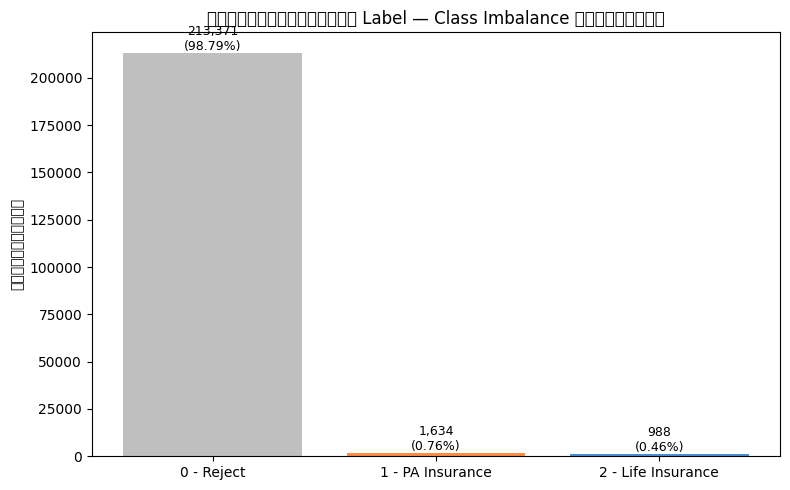

In [61]:
label_counts = df['label'].value_counts().sort_index()
total = label_counts.sum()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['0 - Reject', '1 - PA Insurance', '2 - Life Insurance'],
              label_counts.values, color=['#BFBFBF', '#FF8C42', '#4A90D9'])
for bar, count in zip(bars, label_counts.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{count:,}\n({pct:.2f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('การกระจายตัวของ Label — Class Imbalance รุนแรงมาก')
ax.set_ylabel('จำนวนลูกค้า')
plt.tight_layout()
plt.show()


## Visual 2 — Customer Segment vs Campaign Response (100% Stacked Bar)

 อัตราการตอบรับ offer ภายในแต่ละ segment — เทียบสัดส่วน PA vs Life ระหว่าง Lower/Mass/Upper

/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/3608656560.py:12: UserWarning: Glyph 3616 (\N{THAI CHARACTER PHO SAMPHAO}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/3608656560.py:12: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/3608656560.py:12: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/3608656560.py:12: UserWarning: Glyph 3651 (\N{THAI CHARACTER SARA AI MAIMUAN}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/3608656560.py:12: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/360865

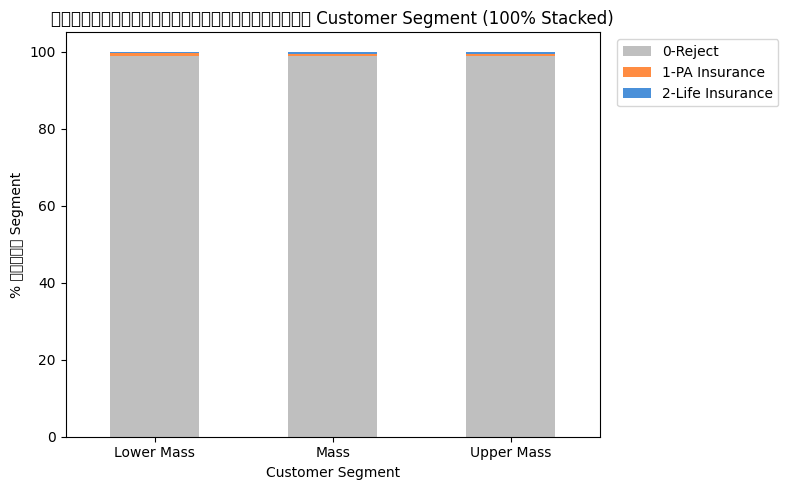

label                 0     1     2
customer_segment                   
Lower Mass        98.74  0.89  0.38
Mass              98.82  0.65  0.53
Upper Mass        98.79  0.53  0.68


In [62]:
ct = pd.crosstab(df['customer_segment'], df['label'], normalize='index') * 100
ct = ct.reindex(['Lower Mass', 'Mass', 'Upper Mass'])

ct.plot(kind='bar', stacked=True, figsize=(8, 5),
        color=['#BFBFBF', '#FF8C42', '#4A90D9'])
plt.title('อัตราการตอบรับแคมเปญแยกตาม Customer Segment (100% Stacked)')
plt.xlabel('Customer Segment')
plt.ylabel('% ภายใน Segment')
plt.legend(['0-Reject', '1-PA Insurance', '2-Life Insurance'],
           bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(ct.round(2))


## Visual 4a — Average Age by Campaign Response

 อายุเฉลี่ยของลูกค้าแต่ละกลุ่ม — ยืนยัน persona ว่ากลุ่มที่ตอบรับ Life Insurance อายุน้อยที่สุด

/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/1755092270.py:12: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/1755092270.py:12: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/1755092270.py:12: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/1755092270.py:12: UserWarning: Glyph 3640 (\N{THAI CHARACTER SARA U}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/1755092270.py:12: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/1755092270.py:12: Us

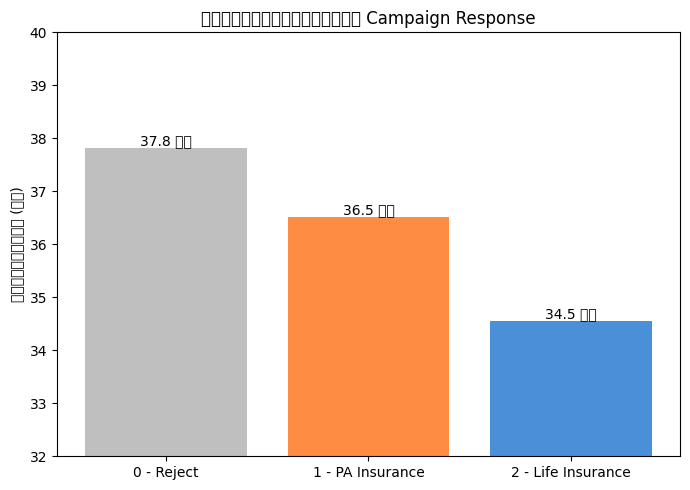

In [63]:
age_avg = df.groupby('label')['age'].mean().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['0 - Reject', '1 - PA Insurance', '2 - Life Insurance'],
              age_avg.values, color=['#BFBFBF', '#FF8C42', '#4A90D9'])
for bar, val in zip(bars, age_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.1f} ปี', ha='center', va='bottom', fontsize=10)
ax.set_title('อายุเฉลี่ยแยกตาม Campaign Response')
ax.set_ylabel('อายุเฉลี่ย (ปี)')
ax.set_ylim(32, 40)  # zoom เพื่อเห็นความต่าง
plt.tight_layout()
plt.show()


## Visual 4b — Average Income by Campaign Response

รายได้เฉลี่ยแต่ละกลุ่ม — ยืนยัน persona ว่ากลุ่ม Life Insurance รายได้สูงสุด

/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/3641150938.py:11: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/3641150938.py:11: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/3641150938.py:11: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/3641150938.py:11: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/3641150938.py:11: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from current font.
  plt.tight_layout()
/var/folders/v4/vqm6gj514tq8rpf37jcyw3wm0000gn/T/ipykernel_46763/364115093

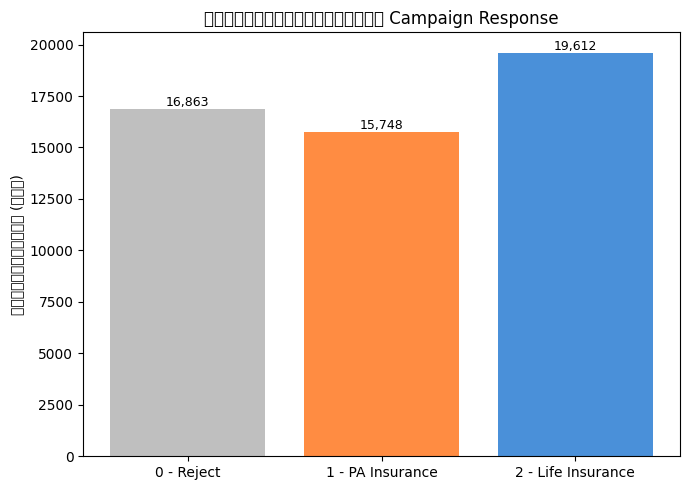

In [64]:
income_avg = df.groupby('label')['income'].mean().round(0)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['0 - Reject', '1 - PA Insurance', '2 - Life Insurance'],
              income_avg.values, color=['#BFBFBF', '#FF8C42', '#4A90D9'])
for bar, val in zip(bars, income_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9)
ax.set_title('รายได้เฉลี่ยแยกตาม Campaign Response')
ax.set_ylabel('รายได้เฉลี่ย (บาท)')
plt.tight_layout()
plt.show()


## Visual 5 — Product Ownership vs Campaign Response

การตอบรับ offer ของลูกค้าที่มี/ไม่มีผลิตภัณฑ์ธนาคาร — เพื่อเห็น cross-sell pattern

In [65]:
rows = []
for col in ['have_cc', 'scb_payroll', 'have_acc_planet']:
    pct = (pd.crosstab(df[col], df['label'], normalize='index') * 100).round(2)
    pct.index = [f'{col} = {v}' for v in pct.index]
    rows.append(pct)

product_table = pd.concat(rows)
product_table.columns = ['Reject (0) %', 'PA Insurance (1) %', 'Life Insurance (2) %']
product_table


,Reject (0) %,PA Insurance (1) %,Life Insurance (2) %
have_cc = N,98.75,0.81,0.44
have_cc = Y,99.03,0.32,0.65
scb_payroll = N,98.82,0.74,0.44
scb_payroll = Y,98.60,0.85,0.54
have_acc_planet = N,98.77,0.77,0.46
have_acc_planet = Y,99.21,0.20,0.58
